# Importing only essential libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Library imported Successfully")

Library imported Successfully


In [35]:
df = pd.read_csv('../dataset/AI-Based Hiring Prediction System.csv')

In [36]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [37]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [39]:
df.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

# As you see Certifications has 274 null value

In [41]:
df['Certifications'] = df['Certifications'].fillna('No Certification')

In [42]:
df.isnull().sum()

Resume_ID                 0
Name                      0
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
AI Score (0-100)          0
dtype: int64

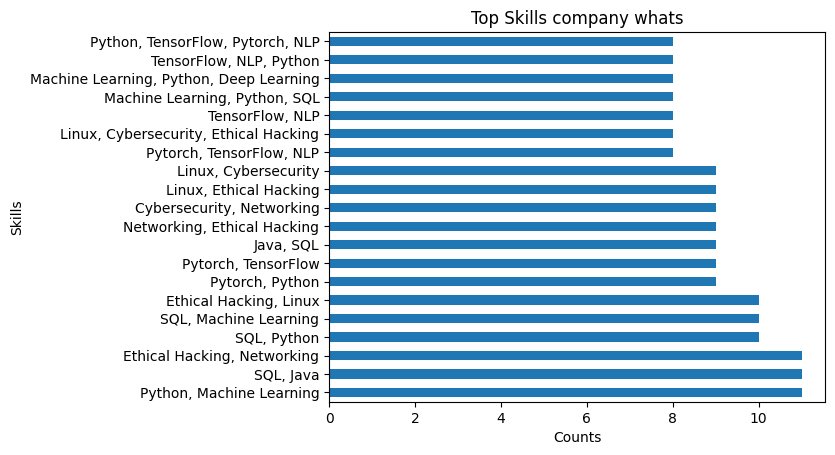

In [43]:
skills = df['Skills'].value_counts().head(20)
skills.plot(kind='barh', rot=0)
plt.title("Top Skills company whats")
plt.xlabel("Counts")
plt.ylabel("Skills")
plt.show()

# Now remove useless columns

In [44]:
print(df.dtypes)

Resume_ID                  int64
Name                      object
Skills                    object
Experience (Years)         int64
Education                 object
Certifications            object
Job Role                  object
Recruiter Decision        object
Salary Expectation ($)     int64
Projects Count             int64
AI Score (0-100)           int64
dtype: object


In [45]:
df = df.drop(['Resume_ID', 'Name'], axis=1)

# Now Recruiter Decision change -'Hire' -> 1 -'Reject' -> 0

In [46]:
df['Recruiter Decision'] = np.where(df['Recruiter Decision'] == 'Hire', 1, 0)

In [47]:
df['Recruiter Decision'].head()

0    1
1    1
2    1
3    1
4    1
Name: Recruiter Decision, dtype: int64

# Converting Str to Int

In [48]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col].astype(str))

In [49]:
print(df.dtypes)

Skills                    int64
Experience (Years)        int64
Education                 int64
Certifications            int64
Job Role                  int64
Recruiter Decision        int64
Salary Expectation ($)    int64
Projects Count            int64
AI Score (0-100)          int64
dtype: object


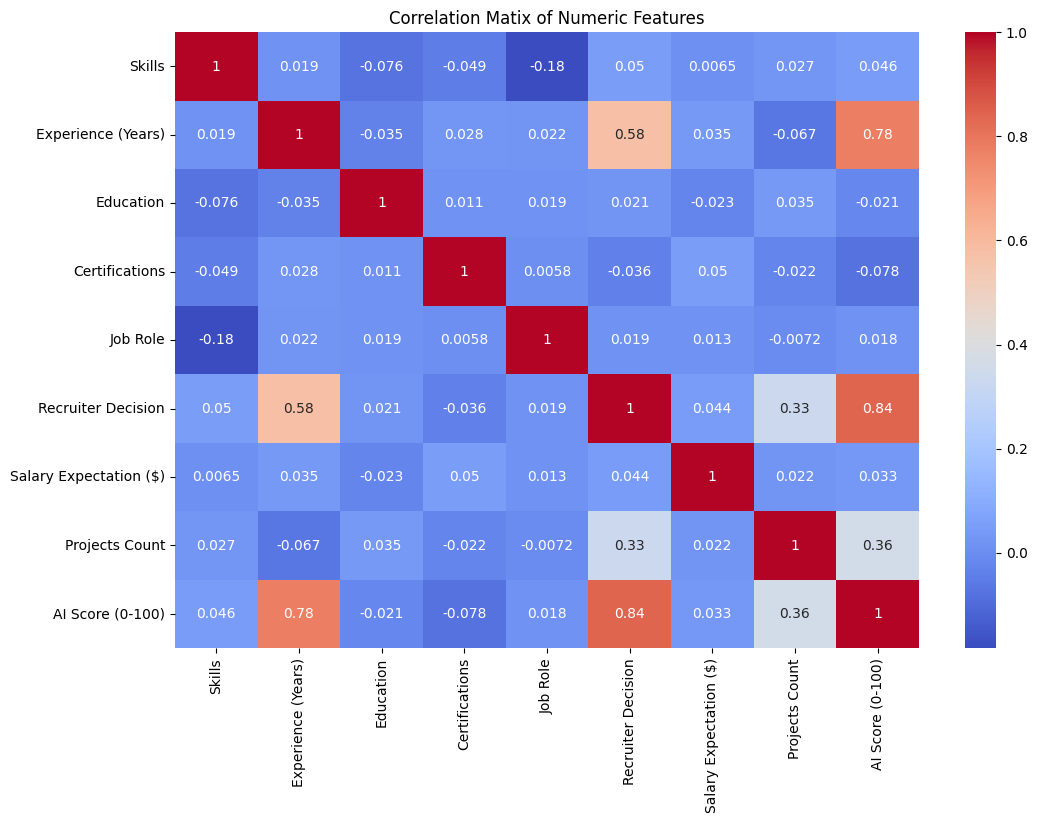

In [50]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.title("Correlation Matix of Numeric Features")
plt.show()

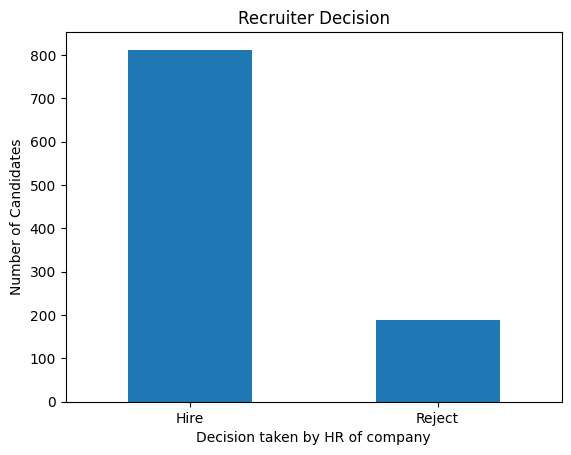

In [51]:
hr_decisions = df['Recruiter Decision'].value_counts()

hr_decisions.plot(kind='bar', rot=0)
plt.xticks([0,1],["Hire", "Reject"])
plt.title("Recruiter Decision")
plt.xlabel("Decision taken by HR of company")
plt.ylabel("Number of Candidates")
plt.show()

# X Train-Test split

In [52]:
X = df.drop(
    columns=[
        "Recruiter Decision",
        "AI Score (0-100)",
        "Resume_ID",
        "Name"
    ],
    errors="ignore"
)

y = df["Recruiter Decision"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# Scaling

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model

In [55]:
lr_model_scaled = LogisticRegression(max_iter=1000)
lr_model_scaled.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
y_pred_scaled = lr_model_scaled.predict(X_test_scaled)

# Models Scores 

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall:", recall_score(y_test, y_pred_scaled))
print("F1 Score:", f1_score(y_test, y_pred_scaled))

Accuracy: 0.965
Precision: 0.9803921568627451
Recall: 0.974025974025974
F1 Score: 0.9771986970684039


In [58]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=32)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    f1 = f1_score(y_test,pred)

    results[name] = f1
    trained_models[name] = model

    print(name)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    print("-" * 30)

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1 Score:", results[best_model_name])

Logistic Regression
Accuracy: 0.9650
Macro F1 Score: 0.9772
------------------------------
KNN
Accuracy: 0.9300
Macro F1 Score: 0.9560
------------------------------
Decision Tree
Accuracy: 0.9650
Macro F1 Score: 0.9772
------------------------------
Best Model: Logistic Regression
Best F1 Score: 0.9771986970684039


# Confussion Matrix

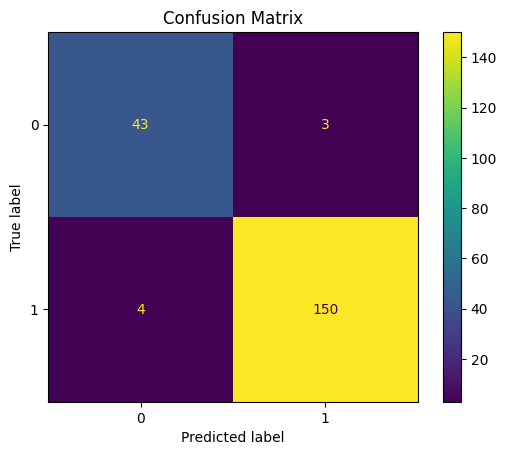

In [59]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled)
plt.title("Confusion Matrix")
plt.show()

# Best Model 

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=32)
}

results = {}
trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    f1 = f1_score(y_test,pred)

    results[name] = f1
    trained_models[name] = model

    print(f"{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 30)

# Select model with highest F1 score
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model is:", best_model_name)
print("Best F1 Score is:", results[best_model_name])

Logistic Regression
Accuracy: 0.9650
F1 Score: 0.9772
------------------------------
KNN
Accuracy: 0.9300
F1 Score: 0.9560
------------------------------
Decision Tree
Accuracy: 0.9650
F1 Score: 0.9772
------------------------------
Best Model is: Logistic Regression
Best F1 Score is: 0.9771986970684039


In [61]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print(
    "Best Parameters:",
    grid.best_params_
)

Best Parameters: {'C': 10}


In [62]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(
    X_test_scaled
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_best
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_best
    )
)

print(
    "Recall:",
        recall_score(
        y_test,
        y_pred_best
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_best
    )
)

Accuracy: 0.97
Precision: 0.9868421052631579
Recall: 0.974025974025974
F1 Score: 0.9803921568627451


In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                  Feature  Coefficient
1      Experience (Years)     9.680028
6          Projects Count     5.180359
0                  Skills     0.246415
4                Job Role     0.237778
2               Education     0.224929
5  Salary Expectation ($)     0.129735
3          Certifications    -0.829873
